# Variance vs Overlap (synthetic, full Monte Carlo)

We vary $(\gamma_\pi, \gamma_\rho) = (\gamma, 0.5\gamma)$ over $\gamma \in [0, 6]$
to create datasets $\mathcal{D}_{t+o}(\gamma)$ with decreasing mixed overlap
$\omega(X) = \rho(X)\,\pi(X)\,(1-\pi(X))$.

**Protocol (full MC).** For each $\gamma$ and each MC repeat $b=0,\ldots,B{-}1$
we sample a *fresh* dataset (with seed $=$ `DATASET_SEED + 1 + b`), train every
learner on it, and predict on a common evaluation grid $X_{\rm eval}$ (drawn
once per $\gamma$ at `DATASET_SEED`). The MC variance therefore reflects both
data sampling *and* learner-side randomness.

$$V(\gamma) = \mathbb{E}_X\bigl[\operatorname{Var}_{\mathcal{D}}(\hat\tau(X))\bigm|\gamma\bigr]$$

We plot $V$ against $\gamma$ for each learner (and save $\mathbb{E}_X[\omega(X)]$
alongside, in case an overlap-axis variant is wanted later).

Base DGP config: `config/dataset/syn-dual-overlap.yaml` (overrides only `gamma`,
`gamma_rho`, `seed`). Learners: T, RA, IPW, DR, LO, TO, DO, TO-2, DO-2.

In [10]:
import sys
from pathlib import Path

project_root = Path().resolve().parent  # R-learner-LTE
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import logging
import warnings
from copy import deepcopy

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logging.getLogger("sklearn").setLevel(logging.ERROR)
logger = logging.getLogger("variance_overlap")

from src.data.synthetic import NieWagerSyntheticDataset
from src.data.utils import load_config, split_two_sample_data
from src.eval_utils import (
    LEARNER_REGISTRY,
    seed_model_cfg,
    swap_cate_regressor_to_nn,
)

In [11]:
DATASET = "syn-dual-overlap"
TRAINER = "default"
MODELS = [
    "T-learner",
    "RA-learner",
    "IPW-learner",
    "DR-learner",
    "LO-learner",
    "TO-learner",
    "DO-learner",
    "TO-learner-2",
    "DO-learner-2",
]

# gamma in [0, 6]; gamma_rho = 0.5 * gamma.
GAMMAS = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
B = 5                  # MC repeats per (gamma, model)
DATASET_SEED = 42      # base seed; eval covariates drawn at this seed,
                       # MC train datasets drawn at DATASET_SEED + 1 + b
NN_BACKBONE = True     # swap stage-2 cate regressor to torch_mlp

OUTPUT_JSON = project_root / "outputs" / "syn_variance_overlap.json"
OUTPUT_PDF  = project_root / "outputs" / "syn_variance_overlap.pdf"

In [ ]:
base_cfg = load_config(
    dataset=DATASET, model=MODELS[0], trainer=TRAINER,
    config_root=project_root / "config",
)

# Pre-build per-model cfg with NN backbone swap (deepcopied per use via seed_model_cfg).
model_cfgs = {}
for m in MODELS:
    cfg_m = load_config(
        dataset=DATASET, model=m, trainer=TRAINER,
        config_root=project_root / "config",
    ).model
    if NN_BACKBONE:
        cfg_m = swap_cate_regressor_to_nn(cfg_m)
    model_cfgs[m] = cfg_m

logger.info("Loaded %d learners; NN backbone=%s", len(MODELS), NN_BACKBONE)


def make_dataset(gamma: float, seed: int):
    """Sample one synthetic dataset at (gamma, gamma_rho=0.5*gamma)."""
    ds_cfg = deepcopy(base_cfg.dataset)
    OmegaConf.set_struct(ds_cfg, False)
    ds_cfg.gamma = float(gamma)
    ds_cfg.gamma_rho = 0.5 * float(gamma)
    ds_cfg.seed = int(seed)
    ds = NieWagerSyntheticDataset(ds_cfg)
    data, gt = ds.sample()
    return ds, data, gt

In [ ]:
results = {m: {"V": [], "gamma": [], "avg_overlap": []} for m in MODELS}
gamma_avg_overlap = []

for gamma in GAMMAS:
    gamma_rho = 0.5 * gamma
    logger.info("=== gamma=%.2f  gamma_rho=%.2f ===", gamma, gamma_rho)

    # Fixed evaluation covariates for this gamma (one draw at DATASET_SEED).
    ds_eval, data_eval, _ = make_dataset(gamma, DATASET_SEED)
    eval_X = data_eval.X_e
    pi_eval  = ds_eval.pi_E(eval_X)
    rho_eval = ds_eval.rho_x(eval_X)
    avg_overlap = float((rho_eval * pi_eval * (1.0 - pi_eval)).mean())
    gamma_avg_overlap.append(avg_overlap)
    logger.info("  n_eval=%d  avg_overlap=%.5f", eval_X.shape[0], avg_overlap)

    # Sample B fresh datasets and train every learner on each draw.
    preds_per_model = {m: [] for m in MODELS}
    for b in range(B):
        ds_b, data_b, _ = make_dataset(gamma, DATASET_SEED + 1 + b)
        logger.info(
            "  [run %d/%d  seed=%d]  n(e,o)=(%d,%d)",
            b + 1, B, DATASET_SEED + 1 + b,
            data_b.X_e.shape[0], data_b.X_o.shape[0],
        )
        for m in MODELS:
            np.random.seed(b)
            torch.manual_seed(b)
            cfg_b = seed_model_cfg(model_cfgs[m], seed=b)
            learner = LEARNER_REGISTRY[m](cfg_b)
            learner.fit(data_b)
            preds_per_model[m].append(learner.predict_cate(eval_X))

    for m in MODELS:
        preds = np.stack(preds_per_model[m], axis=0)   # (B, n_eval)
        pointwise_var = preds.var(axis=0, ddof=1)      # (n_eval,)
        V = float(pointwise_var.mean())
        results[m]["V"].append(V)
        results[m]["gamma"].append(gamma)
        results[m]["avg_overlap"].append(avg_overlap)
        logger.info("  %-14s V=%.6f", m, V)

OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_JSON, "w") as f:
    json.dump(
        {
            "config": {
                "dataset": DATASET,
                "models": MODELS,
                "gammas": GAMMAS,
                "B": B,
                "dataset_seed": DATASET_SEED,
                "nn_backbone": NN_BACKBONE,
            },
            "gamma_avg_overlap": gamma_avg_overlap,
            "results": results,
        },
        f, indent=2,
    )
logger.info("Wrote %s", OUTPUT_JSON)

In [21]:
#load previously stored OUTPUT_JSON for the subsequent plotting
with open(OUTPUT_JSON, "r") as f:
    output = json.load(f)

results = output["results"]
gamma_avg_overlap = output["gamma_avg_overlap"]

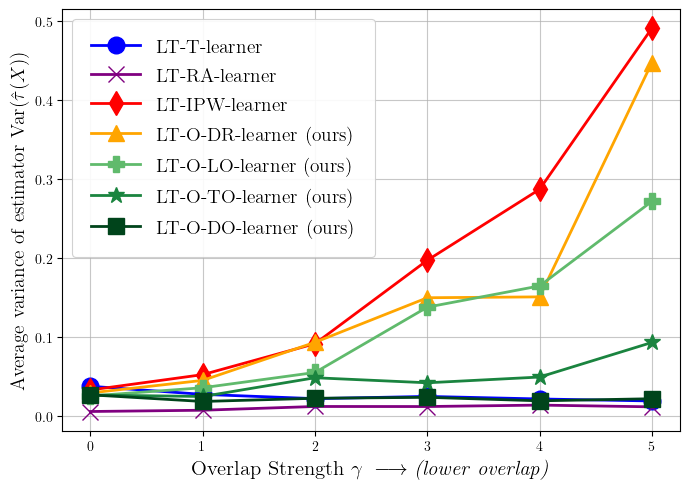

In [24]:
import matplotlib as mpl

# LaTeX rendering for paper-ready labels (mirrors plot_variance_overlap.ipynb).
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})

# Plotting selection: drop linear-weight TO/DO; show the squared variants
# under the canonical TO-learner / DO-learner names.
PLOT_MODELS = [
    "T-learner",
    "RA-learner",
    "IPW-learner",
    "DR-learner",
    "LO-learner",
    "TO-learner-2",   # displayed as TO-learner
    "DO-learner-2",   # displayed as DO-learner
]

# x-axis: gamma in [0, 5]; drop the gamma=6 point.
GAMMA_MAX = 5.0
XLABEL = r"Overlap Strength $\gamma\;\longrightarrow$ \textit{(lower overlap)}"

# Three-tier green for the LTO family (light -> dark, by weighting strength):
#   LO (rho) < TO-2 ((pi(1-pi))^2) < DO-2 ((pi(1-pi))^2 * rho)
_GREEN_LEVELS  = {"LO-learner": 0.55, "TO-learner-2": 0.78, "DO-learner-2": 1.00}
_GREEN_MARKERS = {"LO-learner": "P",  "TO-learner-2": "*",  "DO-learner-2": "s"}
_greens = mpl.colormaps["Greens"]
_lto_styles = {m: dict(marker=_GREEN_MARKERS[m], color=_greens(lvl))
               for m, lvl in _GREEN_LEVELS.items()}

STYLE = {
    "T-learner":    dict(marker="o", color="blue"),
    "RA-learner":   dict(marker="x", color="purple"),
    "IPW-learner":  dict(marker="d", color="red"),
    "DR-learner":   dict(marker="^", color="orange"),
    **_lto_styles,
}

LABEL = {
    "T-learner":    "LT-T-learner",
    "RA-learner":   "LT-RA-learner",
    "IPW-learner":  "LT-IPW-learner",
    "DR-learner":   "LT-O-DR-learner (ours)",
    "LO-learner":   "LT-O-LO-learner (ours)",
    "TO-learner-2": "LT-O-TO-learner (ours)",   # relabeled
    "DO-learner-2": "LT-O-DO-learner (ours)",   # relabeled
}

fig, ax = plt.subplots(figsize=(7, 5))
for m in PLOT_MODELS:
    gammas_m = np.asarray(results[m]["gamma"])
    Vs       = np.asarray(results[m]["V"])
    mask = gammas_m <= GAMMA_MAX
    gammas_m, Vs = gammas_m[mask], Vs[mask]
    order = np.argsort(gammas_m)
    ax.plot(
        gammas_m[order], Vs[order],
        label=LABEL.get(m, m), lw=2, ms=12, **STYLE.get(m, {}),
    )

ax.set_xlabel(XLABEL, fontsize=15)
ax.set_ylabel(r"Average variance of estimator $\operatorname{Var}(\hat{\tau}(X))$", fontsize=14)
legend = ax.legend(frameon=True, borderpad=1., labelspacing=0.6, handlelength=2.5, fontsize=14, ncol=1)
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_linewidth(0.8)
ax.grid(alpha=0.7)
plt.tight_layout()
OUTPUT_PDF.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_PDF, bbox_inches="tight", dpi=300)
plt.show()

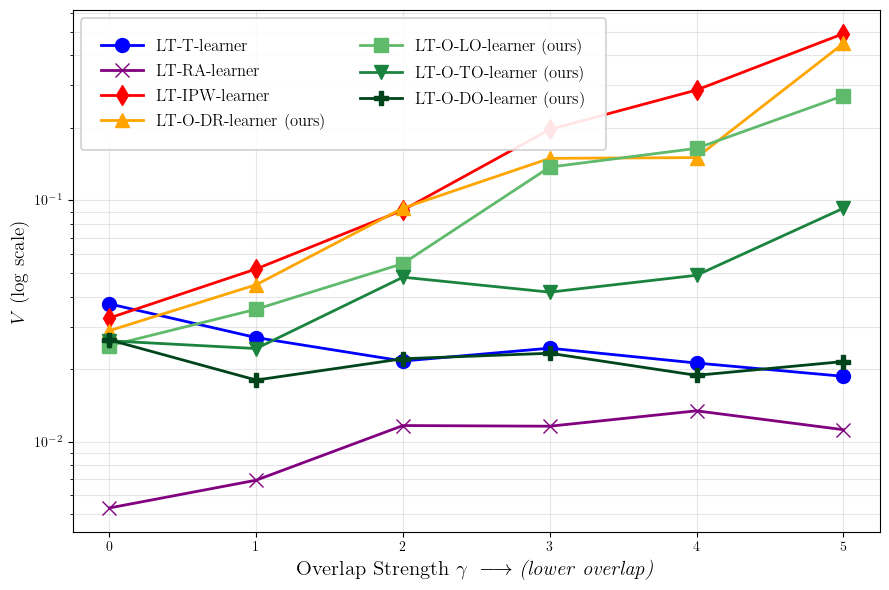

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in PLOT_MODELS:
    gammas_m = np.asarray(results[m]["gamma"])
    Vs       = np.asarray(results[m]["V"])
    mask = gammas_m <= GAMMA_MAX
    gammas_m, Vs = gammas_m[mask], Vs[mask]
    order = np.argsort(gammas_m)
    ax.plot(
        gammas_m[order], Vs[order],
        label=LABEL.get(m, m), lw=2, ms=10, **STYLE.get(m, {}),
    )

ax.set_yscale("log")
ax.set_xlabel(XLABEL, fontsize=15)
ax.set_ylabel(r"$V$ (log scale)", fontsize=14)
legend = ax.legend(frameon=True, borderpad=1.2, labelspacing=0.6, handlelength=2.5, fontsize=12, ncol=2)
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_linewidth(1.2)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(OUTPUT_PDF.with_name("syn_variance_overlap_log.pdf"), bbox_inches="tight", dpi=300)
plt.show()